LIBRARIES

In [25]:
#pip install tensorflow

In [26]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [27]:
IMG_HEIGHT =224
IMG_WIDTH =224
IMG_CHANNELS = 3

CLASS_NAMES = ["lilly", "lotus", "orchid", "sunflower", "tulip"]


In [28]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
                r"C:\My Folder\Projects\Computer_Vision\flower_images\train", 
                labels = 'inferred',
                label_mode ='int',
                batch_size=32,
                image_size=(IMG_HEIGHT, IMG_WIDTH)
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
                r"C:\My Folder\Projects\Computer_Vision\flower_images\val", 
                labels = 'inferred',
                label_mode ='int',
                batch_size=32,
                image_size=(IMG_HEIGHT, IMG_WIDTH)
)
Normalize = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (Normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (Normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [29]:
model = keras.Sequential([

        keras.layers.Flatten(input_shape =(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
        keras.layers.Dense(len(CLASS_NAMES), activation='softmax')

])

model.compile(
        optimizer = 'adam',
        loss = keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics =['accuracy']
)

TRAINING

In [30]:
EPOCHS= 10
history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3503 - loss: 18.4131 - val_accuracy: 0.3410 - val_loss: 11.2829
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4240 - loss: 10.0265 - val_accuracy: 0.3890 - val_loss: 13.9950
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4513 - loss: 8.2859 - val_accuracy: 0.4450 - val_loss: 8.1592
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4763 - loss: 7.2001 - val_accuracy: 0.4320 - val_loss: 7.0611
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4710 - loss: 9.1643 - val_accuracy: 0.3910 - val_loss: 12.5923
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5227 - loss: 6.6458 - val_accuracy: 0.4500 - val_loss: 9.9583
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5313 - loss: 7.4690 - val_accuracy: 0.2620 - val_loss: 21.3186
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5680 - loss: 6.3594 - val_accuracy: 0.44

PLOTTING

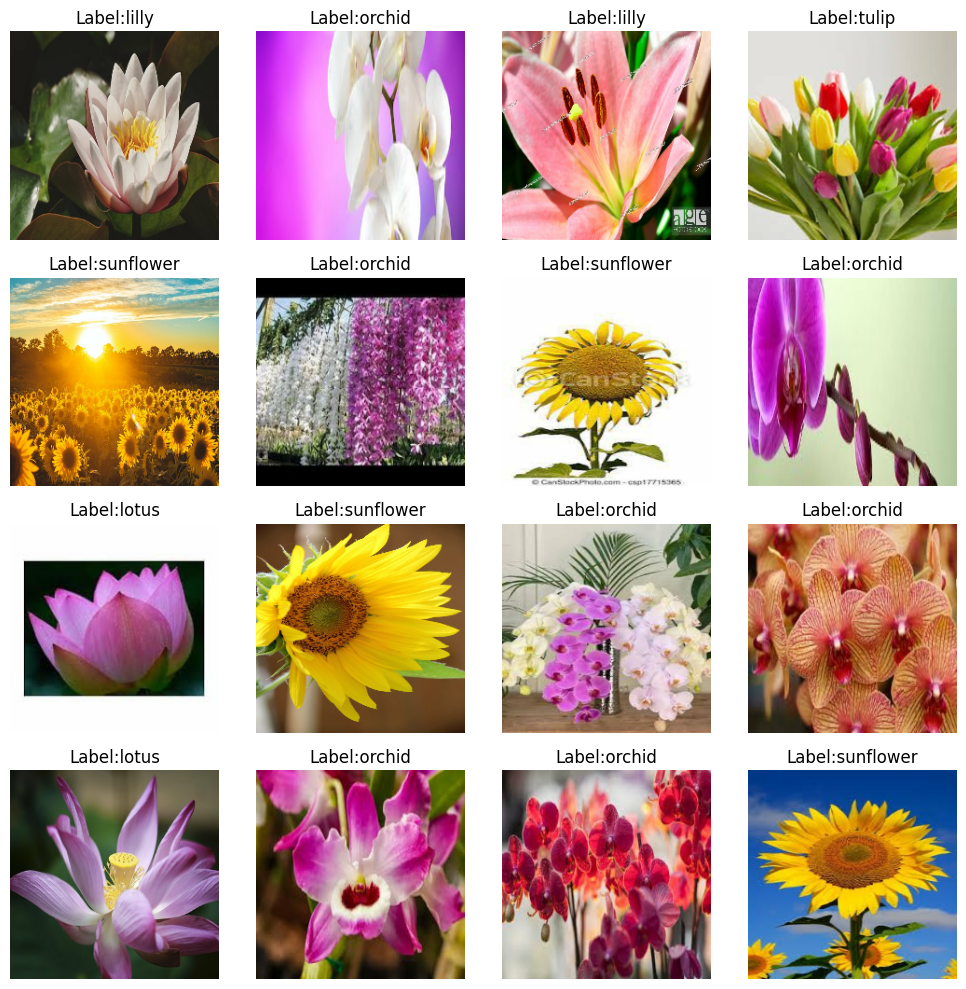

In [31]:
for image, label in train_dataset.take(1):
    fig, axes = plt.subplots(4, 4, figsize = (10, 10))

    for i in range(16):
        ax = axes[i//4, i%4]
        ax.imshow(image[i].numpy())
        ax.set_title(f"Label:{CLASS_NAMES[label[i]]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

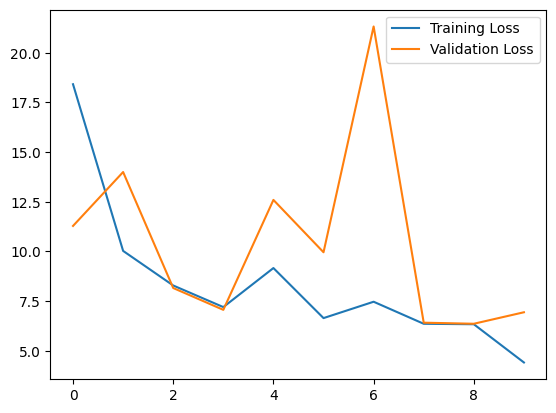

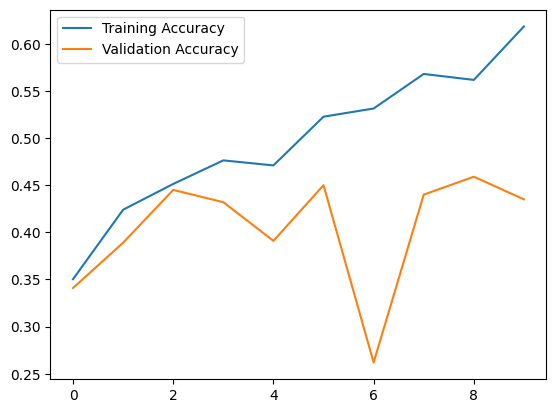

In [32]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label= 'Validation Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label= 'Validation Accuracy')
plt.legend()
plt.show()